In [1]:
import torch
import random
from para_inference import HybridDecoder,EnhancedDecoder
import matplotlib.pyplot as plt
import torch.nn.functional as F

d:\subject\physics\AI4S\project1\FDTDModel300\para_inference.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.spectrum = torch.tensor(spectrum, dtype=torch.float32)
d:\subject\physics\AI4S\project1\FDTDModel300\para_inference.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.pattern = torch.tensor(pattern, dtype=torch.long)


In [2]:
test_model = HybridDecoder()
# test_model = EnhancedDecoder()
test_model.load_state_dict(torch.load("D:/subject/physics/AI4S/project1/model/best_designer_model_0206.pth"))
test_model.eval()
print('model loaded')
pattern = torch.load('D:/subject/physics/AI4S/project1/tensor_data_2000/tensor_data_matrix2000.pt')
spectrum = torch.load('D:/subject/physics/AI4S/project1/tensor_data_2000/tensor_spectrum2000.pt')

model loaded


In [3]:
def draw_pattern(pra):
    pra = pra.detach().numpy()
    fig, ax = plt.subplots()
    ax.imshow(pra, origin='lower')
    plt.xticks([]), plt.yticks([])
    plt.show()

In [4]:
def gen_for_my_model(spectrum):
    logits = test_model(spectrum)
    print(logits.shape)
    probs = F.softmax(logits, dim=1)
    predicted = (probs[:,1,:,:] > 0.5).squeeze().float()
    print("test answer")
    draw_pattern(predicted)
def gen_for_standard(pattern_test): 
    print("real answer")
    draw_pattern(pattern_test)

In [ ]:
from MetasurfaceCNN import Meta_CNN_Net
model = Meta_CNN_Net()
checkpoint = torch.load('./logs/b512_adam_lr0.001_c1281WCNN/checkpoint_max.pth', map_location='cpu')
model.load_state_dict(checkpoint['net'])
model.eval()

In [15]:
idx = random.randint(0,2000)
pattern_test = pattern[idx]
spectrum_test = spectrum[idx,1:7,:]
# Reshape to (1, 1206)
spectrum_reshaped = spectrum_test.reshape(1, -1)
print("idx=",idx)


idx= 457


torch.Size([1, 2, 400, 400])
test answer


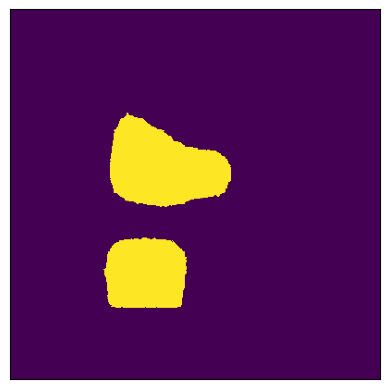

real answer


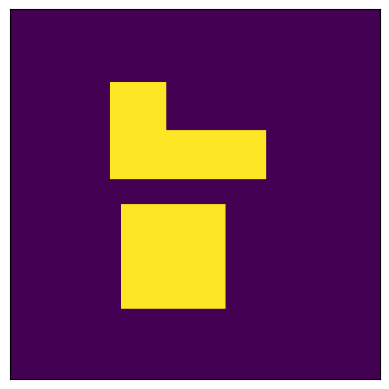

In [16]:
gen_for_my_model(spectrum_reshaped)
gen_for_standard(pattern_test)

In [101]:
y_predict = model(pattern_test.unsqueeze(0).unsqueeze(0).float()).detach().numpy()
print(y_predict[0])
print('')
print(spectrum_test.numpy())

[[ 0.08471566  0.08469453  0.06817825 ...  0.19728681  0.1835767
   0.19675222]
 [ 0.01286954  0.03068328  0.01755109 ... -0.08374657 -0.08621214
  -0.08855928]
 [ 0.04970593  0.04395511  0.04707503 ... -0.14047626 -0.13091573
  -0.13346657]
 [-0.01707677 -0.03108342  0.00792958 ... -0.18879274 -0.20278504
  -0.19299835]
 [ 0.5408716   0.5504968   0.53043675 ...  0.23704341  0.23768076
   0.23031034]
 [ 0.06388531  0.05956993  0.04060442 ...  0.13693938  0.14596793
   0.14757432]]

[[ 0.09394857  0.09123478  0.08850417 ... -0.03224882 -0.03692827
  -0.04165369]
 [ 0.01798252  0.01402212  0.0102626  ... -0.60039085 -0.602159
  -0.6038422 ]
 [ 0.01406078  0.00435706 -0.00411822 ... -0.44294852 -0.44701996
  -0.45109287]
 [-0.11747171 -0.11221454 -0.10461606 ... -0.4252006  -0.42367935
  -0.4221508 ]
 [ 0.76440775  0.780224    0.7945736  ...  0.62990576  0.62596524
   0.62199575]
 [ 0.18574235  0.17682026  0.16512935 ... -0.13204059 -0.13345467
  -0.13481593]]


tensor([[ 0.0939,  0.0912,  0.0885,  ..., -0.0322, -0.0369, -0.0417],
        [ 0.0180,  0.0140,  0.0103,  ..., -0.6004, -0.6022, -0.6038],
        [ 0.0141,  0.0044, -0.0041,  ..., -0.4429, -0.4470, -0.4511],
        [-0.1175, -0.1122, -0.1046,  ..., -0.4252, -0.4237, -0.4222],
        [ 0.7644,  0.7802,  0.7946,  ...,  0.6299,  0.6260,  0.6220],
        [ 0.1857,  0.1768,  0.1651,  ..., -0.1320, -0.1335, -0.1348]])
